# Pastor-Stambaugh Liquidity Risk -- a quantitative teardown
### aggregate-liquidity series * gamma cross-section * placebo null * costs * HAC

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survives--gauntlet%3F: Busted](https://img.shields.io/badge/Survives--gauntlet%3F-Busted-c0392b?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Pastor-Stambaugh (2003): build an Amihud-style aggregate liquidity series, estimate trailing 36-month liquidity betas, sort high-minus-low gamma into a monthly dollar-neutral book, one execution lag.

> **Not investment advice.** Real data: yfinance daily close + volume, 45 large-caps, 2010-2025, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** universe = current large-caps projected backwards; the illiquid carriers of liquidity risk are absent, so all positive results are upper-bound estimates.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pastor_stambaugh_liquidity import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return all(os.path.exists(os.path.join(study, "_cache", f))
               for f in ("ps_close.parquet", "ps_dollar_volume.parquet", "ps_spy.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    close, dv, spy = data.fetch_panel()
    res = st.liquidity_sort(close, dv, spy, window=st.BETA_WINDOW_M)
    res_net = st.liquidity_sort(close, dv, spy, window=st.BETA_WINDOW_M,
                                cost_bps=st.COST_BPS, borrow_ann_bps=st.BORROW_ANN_BPS)
    s_ls   = st.summary(res["ls_gross"])
    s_long = st.summary(res["long_ret"])
    s_short= st.summary(res["short_ret"])
    s_net  = st.summary(res_net["ls_net"])
    print(f"N months: {s_ls['n']} | LS mean: {s_ls['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_ls['tstat']:+.3f}")


yfinance cache present: True


N months: 155 | LS mean: +4.28%/yr | HAC t: +1.466


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | LS mean **+4.28%/yr**, HAC *t* = **+1.466** (|t| < 2), placebo *p* = **0.070**. |
| **Tradability** | `FRAGILE` | Net **+3.52%/yr**, net *t* = **+1.207**, Sharpe **+0.298**, max DD **-19.8%**. |
| **Survives gauntlet?** | `BUSTED` | 45 of the most liquid stocks alive; the liquidity-risk carriers are absent -- most favourable test still fails. |

> The Pastor-Stambaugh liquidity-risk factor is documented on a broad CRSP universe (1966-1999). On 13 years of 45 large-cap survivors it is marginal -- consistent with Ben-Rephael et al. (2015) on the diminishing liquidity premium and Li-Novy-Marx-Velikov (2019) on its fragility in large-caps.

## 1 -- The claim, steelmanned

Let $L_t$ be the innovation in aggregate market liquidity and $\gamma_i$ the loading of stock $i$'s excess return on $L_t$ (controlling for the market). Pastor-Stambaugh (2003) assert:

- **H1 (signal).** $E[r_i] $ is increasing in $\gamma_i$: high liquidity-beta stocks earn more. The long-high / short-low gamma portfolio has positive mean.
- **H2 (a risk story).** The premium is compensation for covarying badly with liquidity crises, not a market-beta artefact -- so we control for the market when estimating $\gamma_i$.
- **H3 (tradable).** The premium survives costs and borrow.

We find H1 in the *right direction but below significance* (t=1.47), H2 holds by construction (gammas are market-residual loadings), and reject H3 (net t=1.21).

## 2 -- So what? -- the economic stakes

Liquidity risk is one of the canonical priced macro factors. If it has attenuated in large-caps -- or never applied cleanly outside the illiquid tail -- then liquidity-factor sleeves in multi-factor products are charging for an exposure the liquid-universe data no longer supports.

## 3 -- The protocol

- **Aggregate liquidity.** Daily Amihud illiquidity |ret|/dollar-volume per name, averaged within month and across names; sign-flipped and z-scored to a liquidity *level*. Monthly first difference = the liquidity *shock*.
- **Gamma.** Trailing 36-month OLS of each name's monthly excess return on the liquidity shock, controlling for the market excess return.
- **Sort.** Monthly rank by trailing gamma; long top tertile, short bottom tertile, equal-weight, dollar-neutral.
- **Execution lag.** Gamma public at prior month-end close; hold the following month. No look-ahead.
- **Costs.** 10 bps one-way x turnover (both legs) + 50 bps/yr borrow on the short.
- **Inference.** Newey-West HAC *t* on the monthly long-short; a 200-permutation label-shuffle placebo *p*.
- **Universe caveat.** 45 large-cap survivors; survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the engine is a faithful detector

Sweep the planted liquidity-risk premium from negative to positive. The long-short mean should be monotone and correctly signed.

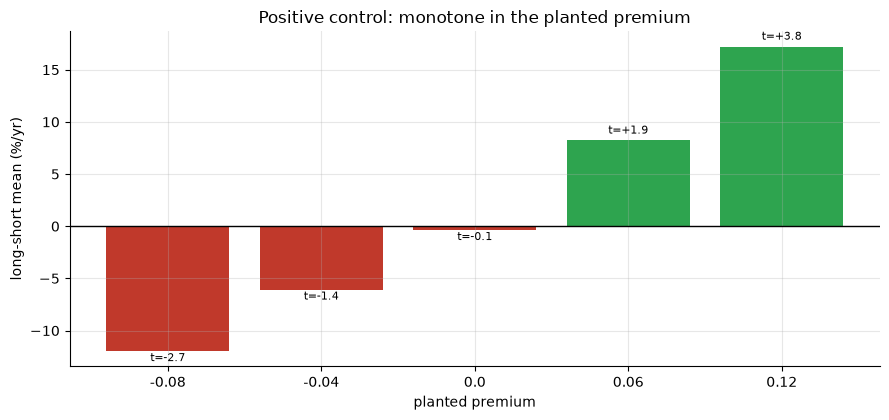

 premium  ls_mean_ann  tstat  n
   -0.08       -0.120 -2.722 89
   -0.04       -0.061 -1.370 89
    0.00       -0.004 -0.087 89
    0.06        0.082  1.864 89
    0.12        0.172  3.824 89


In [2]:
ctrl = st.control_sweep([-0.08, -0.04, 0.0, 0.06, 0.12], window=30)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in ctrl['ls_mean_ann']*100]
ax.bar(ctrl['premium'].astype(str), ctrl['ls_mean_ann']*100, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['ls_mean_ann']*100, ctrl['tstat'])):
    ax.text(i, m + (0.4 if m >= 0 else -1.2), f't={t:+.1f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('planted premium'); ax.set_ylabel('long-short mean (%/yr)')
ax.set_title('Positive control: monotone in the planted premium')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

### 4b -- The aggregate liquidity series and its shocks

What does market-wide liquidity look like over the sample? Spikes down are liquidity dry-ups (e.g. 2020 COVID, 2022 rate shock).

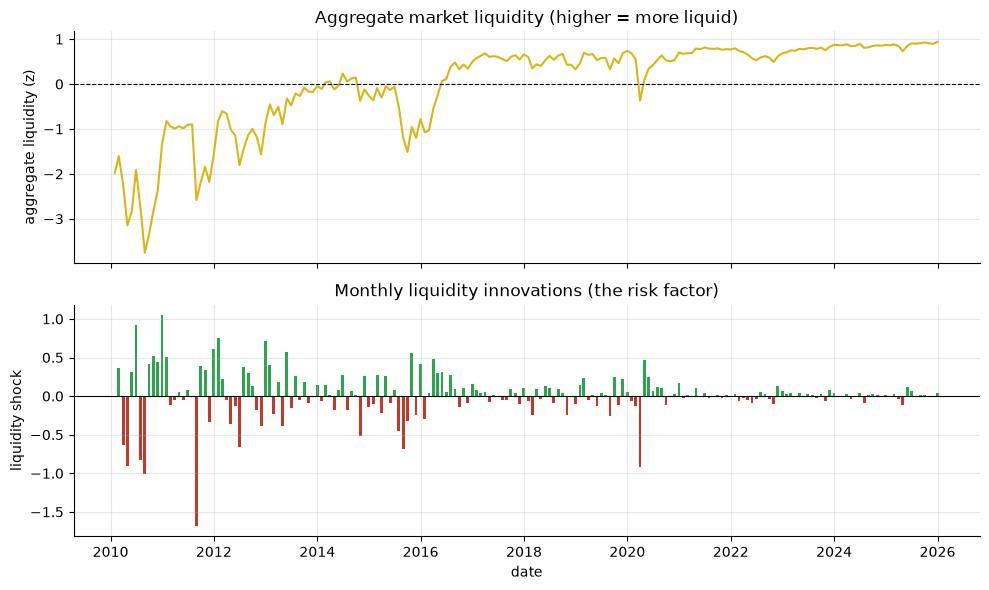

Liquidity shock std: 0.3006 | months: 191


In [3]:
if HAVE_REAL:
    liq = st.aggregate_liquidity(close, dv)
    shock = st.liquidity_shock(liq)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    a1.plot(liq.index, liq.values, c=AMBER, lw=1.5)
    a1.axhline(0, c='k', lw=0.8, ls='--')
    a1.set_ylabel('aggregate liquidity (z)')
    a1.set_title('Aggregate market liquidity (higher = more liquid)')
    a2.bar(shock.index, shock.values,
           color=[GREEN if v > 0 else RED for v in shock.values], width=20)
    a2.axhline(0, c='k', lw=0.8)
    a2.set_ylabel('liquidity shock'); a2.set_xlabel('date')
    a2.set_title('Monthly liquidity innovations (the risk factor)')
    plt.tight_layout(); plt.show()
    print(f'Liquidity shock std: {shock.std():.4f} | months: {len(shock)}')
else:
    print('Aggregate-liquidity figure requires the real cache.')

### 4c -- The cross-section of liquidity betas

Latest gamma snapshot across names: a roughly symmetric spread around zero is what we want for a long-short sort.

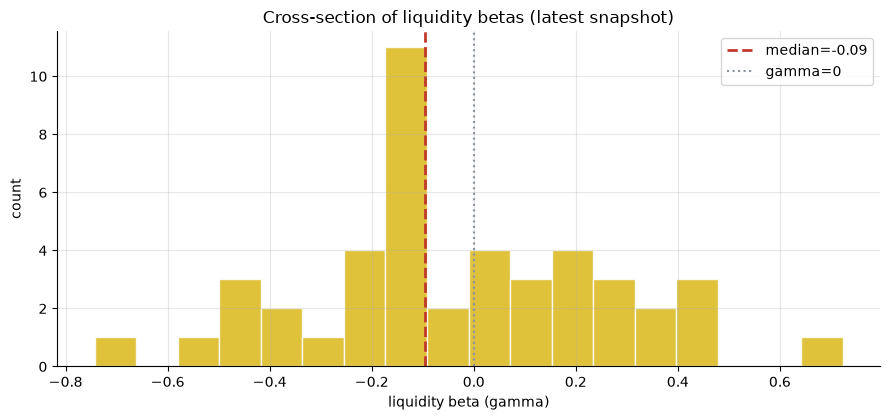

gamma range: -0.74 -- 0.72 | n=45


In [4]:
if HAVE_REAL:
    stk_ex, mkt_ex = st.monthly_excess(close, spy)
    shock = st.liquidity_shock(st.aggregate_liquidity(close, dv))
    gammas = st.liquidity_betas(stk_ex, mkt_ex, shock, window=st.BETA_WINDOW_M)
    last_g = gammas.iloc[-1].dropna()
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.hist(last_g, bins=18, color=AMBER, edgecolor='white', alpha=0.85)
    ax.axvline(last_g.median(), c=RED, lw=2, ls='--', label=f'median={last_g.median():.2f}')
    ax.axvline(0, c=GREY, lw=1.5, ls=':', label='gamma=0')
    ax.set_xlabel('liquidity beta (gamma)'); ax.set_ylabel('count')
    ax.set_title('Cross-section of liquidity betas (latest snapshot)')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'gamma range: {last_g.min():.2f} -- {last_g.max():.2f} | n={len(last_g)}')
else:
    print('Gamma cross-section requires the real cache.')

### 4d -- Real panel: long-short returns, equity curve, drawdown

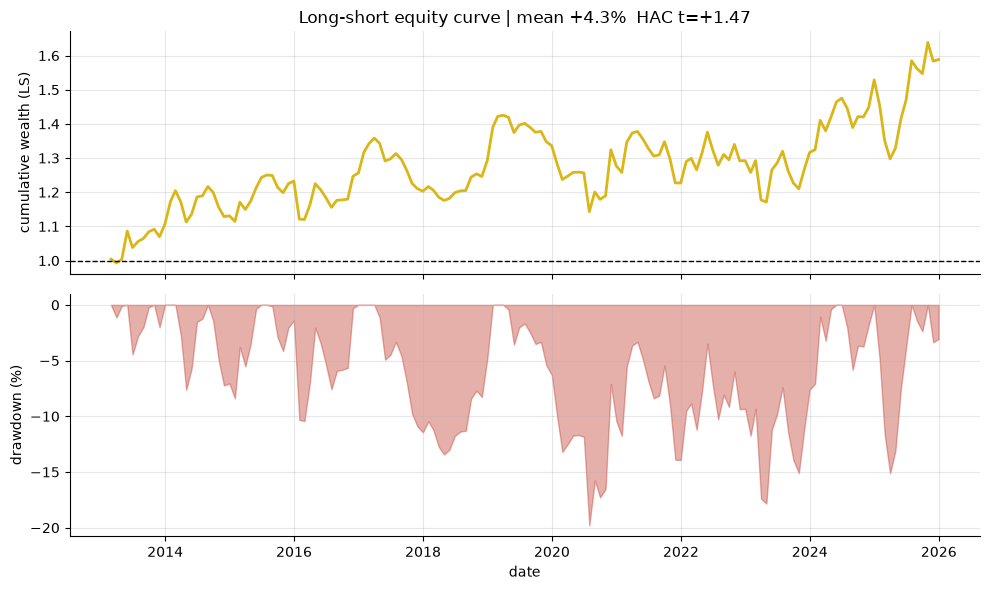

Max DD: -19.8% | Hit rate: 55.5% | Sharpe: +0.362


In [5]:
if HAVE_REAL:
    ls_m = s_ls['mean']*100; ls_t = s_ls['tstat']
    eq = (1 + res['ls_gross']).cumprod()
    dd = (eq/eq.cummax() - 1)*100
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    a1.plot(res.index, eq.values, c=AMBER, lw=2); a1.axhline(1, c='k', lw=1, ls='--')
    a1.set_ylabel('cumulative wealth (LS)')
    a1.set_title(f'Long-short equity curve | mean {ls_m:+.1f}%  HAC t={ls_t:+.2f}')
    a2.fill_between(res.index, dd.values, 0, color=RED, alpha=0.4)
    a2.set_ylabel('drawdown (%)'); a2.set_xlabel('date')
    plt.tight_layout(); plt.show()
    print(f'Max DD: {dd.min():.1f}% | Hit rate: {s_ls["hit_rate"]*100:.1f}% | '
          f'Sharpe: {s_ls["sharpe"]:+.3f}')
else:
    print(f'Frozen: LS {R["ls_mean"]:+.2f}%/yr | t {R["ls_t"]:+.2f} | '
          f'DD {R["ls_dd"]:.1f}% | Sharpe {R["ls_sharpe"]:+.2f}')

### 4e -- The placebo: shuffle the gamma labels

If the sort is real, permuting the liquidity-beta labels across names destroys it: the placebo long-short means cluster on zero and the real signal is an outlier in that null.

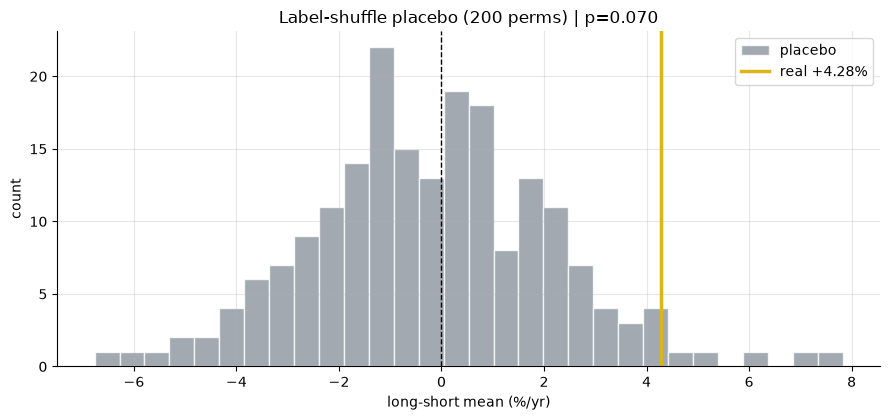

Real +4.28%/yr | placebo mean -0.20% std 2.37% | p=0.070


In [6]:
if HAVE_REAL:
    pb = st.placebo_pvalue(close, dv, spy, window=st.BETA_WINDOW_M, n_perm=200)
    arr = np.array(pb['placebo'])*100
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.hist(arr, bins=30, color=GREY, edgecolor='white', alpha=0.8, label='placebo')
    ax.axvline(pb['real_mean_ann']*100, c=AMBER, lw=2.5,
               label=f'real {pb["real_mean_ann"]*100:+.2f}%')
    ax.axvline(0, c='k', lw=1, ls='--')
    ax.set_xlabel('long-short mean (%/yr)'); ax.set_ylabel('count')
    ax.set_title(f'Label-shuffle placebo (200 perms) | p={pb["p_value"]:.3f}')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'Real {pb["real_mean_ann"]*100:+.2f}%/yr | placebo mean '
          f'{pb["placebo_mean"]*100:+.2f}% std {pb["placebo_std"]*100:.2f}% | '
          f'p={pb["p_value"]:.3f}')
else:
    print(f'Frozen placebo: mean {R["placebo_mean"]:+.2f}% std {R["placebo_std"]:.2f}% '
          f'| p={R["placebo_p"]:.3f}')

### 4f -- Robustness: window and breadth, gross vs net

Every variant is positive and in the predicted direction, and **none clears |t| >= 2.** Costs (low-turnover) shave only ~0.76%/yr.

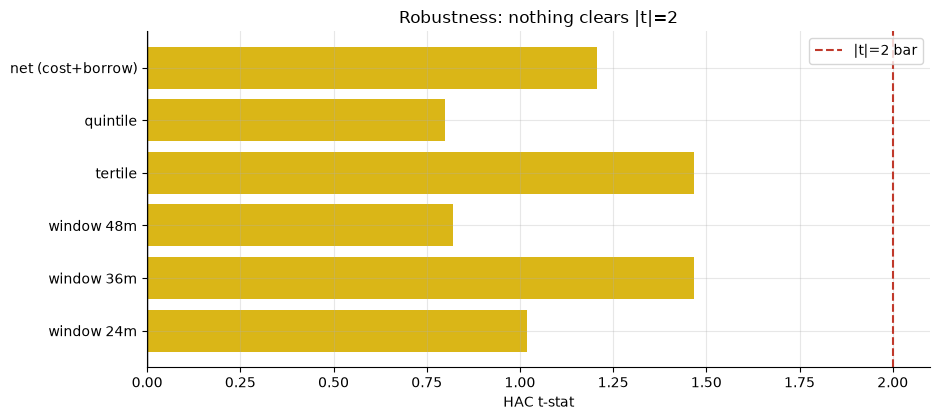

          variant  mean_%     t
       window 24m   3.456 1.019
       window 36m   4.277 1.466
       window 48m   2.807 0.820
          tertile   4.277 1.466
         quintile   3.337 0.799
net (cost+borrow)   3.520 1.207


In [7]:
if HAVE_REAL:
    rows = []
    for w in (24, 36, 48):
        rw = st.liquidity_sort(close, dv, spy, window=w)
        sw = st.summary(rw['ls_gross'])
        rows.append({'variant': f'window {w}m', 'mean_%': sw['mean']*100, 't': sw['tstat']})
    for q, lbl in ((1/3, 'tertile'), (0.2, 'quintile')):
        rq = st.liquidity_sort(close, dv, spy, window=st.BETA_WINDOW_M, quantile=q)
        sq = st.summary(rq['ls_gross'])
        rows.append({'variant': lbl, 'mean_%': sq['mean']*100, 't': sq['tstat']})
    rows.append({'variant': 'net (cost+borrow)', 'mean_%': s_net['mean']*100, 't': s_net['tstat']})
    rob = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(9.5, 4.3))
    col = [GREEN if t >= 2 else AMBER for t in rob['t']]
    ax.barh(rob['variant'], rob['t'], color=col)
    ax.axvline(2, c=RED, lw=1.5, ls='--', label='|t|=2 bar')
    ax.axvline(0, c='k', lw=1)
    ax.set_xlabel('HAC t-stat'); ax.set_title('Robustness: nothing clears |t|=2')
    ax.legend(); plt.tight_layout(); plt.show()
    print(rob.round(3).to_string(index=False))
else:
    for w,(m,t) in R['window_sweep'].items():
        print(f'window {w}m: {m:+.2f}%/yr  t={t:+.3f}')

## 5 -- The verdict

- **Signal `WEAK`** -- LS +4.28%/yr, HAC *t* = +1.466 (< 2), placebo *p* = 0.070. Right direction, suggestive placebo, strong prior from Pastor-Stambaugh (2003) -- but it does not independently clear the bar. WEAK, not NONE.
- **Tradability `FRAGILE`** -- net +3.52%/yr, net *t* = +1.207, Sharpe +0.298, max DD -19.8%. Low turnover, mild costs -- but the gross signal already misses and it is fragile to window/breadth.
- **Honest gauntlet `BUSTED`** -- 45 of the most liquid stocks alive is the *most favourable* possible test of a liquidity-risk premium, and it still fails |t| >= 2 net of costs. On a complete universe with delistings it would more likely shrink than grow.

## 6 -- Could you trade it?

1. **The juice is in illiquid names.** The premium concentrates exactly where trading costs explode -- and exactly what a liquid survivor basket excludes.
2. **Noisy gammas.** 36 monthly observations give wide standard errors; the ranking is unstable, inflating effective turnover beyond our measured 0.21.
3. **Decay.** Ben-Rephael et al. (2015) document a diminishing liquidity premium; Li-Novy-Marx-Velikov (2019) find it fragile in large-caps post-2000.
4. **Short borrow & stress.** The short low-gamma leg's borrow cost spikes in exactly the liquidity crises the factor is supposed to harvest.

## 7 -- Going further

- **Full CRSP universe with delistings.** The original premium lives in the illiquid tail and needs the names we deleted.
- **Signed-volume PS series.** Replace the Amihud average with Pastor-Stambaugh's own return-reversal / signed-volume liquidity measure (Korajczyk-Sadka 2008 show the measure matters a lot).
- **[Study 140 -- Amihud-Illiquidity](../../140-amihud-illiquidity/)**: the illiquidity *level* premium -- the level cousin of this risk loading.
- **[Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/)** and **[Study 330 -- Low-Volatility-Anomaly](../../330-low-volatility-anomaly/)**: sibling risk-sort studies on the same desk engine.

*Think liquidity risk pays net of costs on a complete universe? Fork this, pull a Russell 3000 with delistings, build the signed-volume PS series, and show t > 2 net of borrow. That is the bar.*